Convolucionales CNN

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

%matplotlib inline

In [2]:
data = pd.read_csv("daily_minimum_temperatures.csv", sep=",")
print(data.shape)
data.head()

(3650, 2)


,Date,"Daily minimum temperatures in Melbourne, Australia, 1981-1990"
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


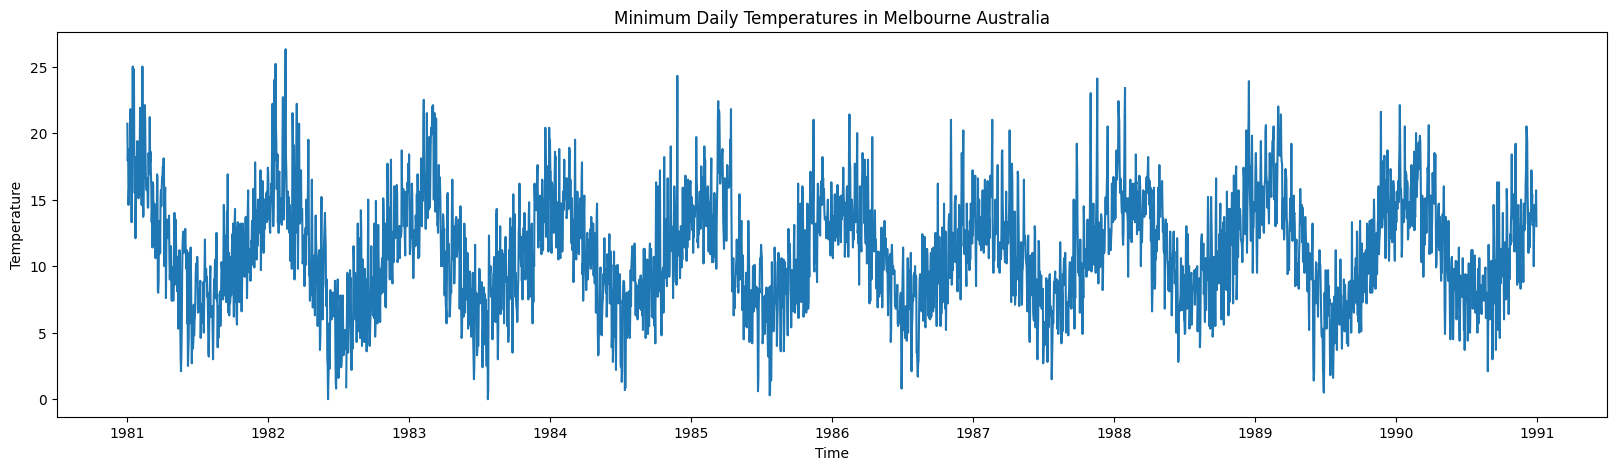

In [3]:
plt.figure(figsize = [20,5])

# Uso ['Temp'] para evitar el error de atributo que tuviste antes
col = data.columns[1]
data['Date'] = pd.to_datetime(data['Date'])
data[col] = pd.to_numeric(data[col], errors='coerce')
plt.plot(data['Date'], data[col])

plt.title("Minimum Daily Temperatures in Melbourne Australia")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.show()

In [4]:
train_percentage = 0.67
train_size = int(len(data) * train_percentage)

# Extracción de valores y conversión a float
train = data[col][:train_size].values.astype(float)
test = data[col][train_size:].values.astype(float)

# Escalado de los datos (Normalización)
sc = MinMaxScaler(feature_range=(-1, 1))
train_norm = sc.fit_transform(train.reshape(-1, 1))

# Conversión a Tensor de PyTorch y aplanado
train_norm = torch.FloatTensor(train_norm).view(-1)

In [5]:
np.shape(train_norm)
# Salida esperada: torch.Size([2445])

torch.Size([2445])

In [6]:
def create_input_output(input_data, window, ndays = 1):
    input_output = []
    data_size = len(input_data)
    
    for i in range(data_size - window - ndays):
        train_seq = input_data[i:i+window]
        train_label = input_data[i+window+ndays : i+window+ndays+1]
        input_output.append((train_seq, train_label))
        
    return input_output

# Configuración de la ventana
ndays = 10
window = 30

# Generación de los datos de entrenamiento
train_input_output = create_input_output(train_norm, window, ndays)

# Vista previa de los primeros 2 elementos
train_input_output[:2]

[(tensor([ 0.5741,  0.3612,  0.4297,  0.1103,  0.2015,  0.2015,  0.2015,  0.3232,
           0.6578,  0.5209,  0.2319,  0.0114,  0.2700,  0.6350,  0.9011,  0.5741,
           0.5665,  0.8859,  0.3460,  0.1787,  0.3840, -0.0798,  0.0951,  0.2167,
           0.2548,  0.4221,  0.4753,  0.3080,  0.1787,  0.1483]),
  tensor([0.1407])),
 (tensor([ 0.3612,  0.4297,  0.1103,  0.2015,  0.2015,  0.2015,  0.3232,  0.6578,
           0.5209,  0.2319,  0.0114,  0.2700,  0.6350,  0.9011,  0.5741,  0.5665,
           0.8859,  0.3460,  0.1787,  0.3840, -0.0798,  0.0951,  0.2167,  0.2548,
           0.4221,  0.4753,  0.3080,  0.1787,  0.1483,  0.1711]),
  tensor([0.0418]))]

In [7]:
# Documentation of pytorch Conv1D: https://pytorch.org/docs/stable/generated/torch.nn.Conv1d.html
class NN_conv(nn.Module):
    def __init__(self):
        super(NN_conv, self).__init__()
        
        self.conv1 = nn.Sequential(
            nn.Conv1d(
                in_channels=1,      # Number of channels in the input image
                out_channels=5,     # Number of channels produced by the convolution
                kernel_size=5,      # Size of the convolving kernel
                stride=1,           # Stride of the convolution. Default: 1
                padding=2,          # Zero-padding added to both sides of the input. Default: 0
            ),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3),
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv1d(
                in_channels=5,
                out_channels=8,
                kernel_size=5,
                stride=1,
                padding=2,
            ),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
        )
        
        self.out = nn.Linear(40, 1) # output 3 classes: Cargo, Passenger or Fishing


    def forward(self, x):
            #print(x.size())
            x = self.conv1(x)
            #print(x.size())
            x = self.conv2(x)
            #print(x.size())
            
            # El -1 mantiene el tamaño del batch, mientras que 8 * 5 (40) aplana los datos
            x = x.view(-1, 8 * 5)
            #print(x.size())
            
            output = self.out(x)
            return output

net = NN_conv()

In [18]:
model = NN_conv()
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) #torch.optim.SGD(model.parameters(), lr=0.001)

In [9]:
epochs = 100

for i in range(epochs):
    for inputs, labels in train_input_output:
        optimizer.zero_grad()
        
        # Reformateamos la entrada para Conv1D: (Batch, Channels, Length)
        # N=1 (un ejemplo a la vez), C=1 (una sola serie), L=window (30 días)
        inputs = inputs.view(1, 1, window) 
        
        y_pred = model(inputs)
        
        single_loss = loss_function(y_pred, labels)
        single_loss.backward() # Backpropagation
        optimizer.step()       # Actualización de pesos
        
    if i % 10 == 1:
        print(f'epoch: {i:3} loss: {single_loss.item():10.8f}')

print(f'epoch: {i:3} loss: {single_loss.item():10.10f}')

c:\Users\Matias\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


epoch:   1 loss:        nan
epoch:  11 loss:        nan
epoch:  21 loss:        nan
epoch:  31 loss:        nan
epoch:  41 loss:        nan
epoch:  51 loss:        nan
epoch:  61 loss:        nan
epoch:  71 loss:        nan
epoch:  81 loss:        nan
epoch:  91 loss:        nan
epoch:  99 loss:        nan


In [10]:
test_norm = sc.transform(test.reshape(-1, 1))
test_norm = torch.FloatTensor(test_norm).view(-1)
test_input_output = create_input_output(test_norm, window, ndays)
test_input_output[:2]

[(tensor([-0.4829, -0.2928, -0.2548, -0.1863, -0.4068, -0.3004,  0.1407, -0.4068,
          -0.5970, -0.2776, -0.4221,  0.0646,  0.1331,  0.1331,  0.4601,  0.2928,
          -0.0114, -0.1483, -0.2776, -0.2167, -0.2928, -0.1407, -0.5057, -0.0875,
          -0.3688, -0.3384, -0.3384, -0.2243, -0.4753, -0.6274]),
  tensor([-0.2015])),
 (tensor([-0.2928, -0.2548, -0.1863, -0.4068, -0.3004,  0.1407, -0.4068, -0.5970,
          -0.2776, -0.4221,  0.0646,  0.1331,  0.1331,  0.4601,  0.2928, -0.0114,
          -0.1483, -0.2776, -0.2167, -0.2928, -0.1407, -0.5057, -0.0875, -0.3688,
          -0.3384, -0.3384, -0.2243, -0.4753, -0.6274, -0.2395]),
  tensor([-0.1331]))]

In [11]:
y_pred_norm = []
for inputs, labels in test_input_output:
    with torch.no_grad(): # Desactiva el cálculo de gradientes (ahorra memoria y tiempo)
        inputs = inputs.view(1, 1, window)
        y_pred_norm.append(model(inputs).item())

y_pred_norm[:5]

[nan, nan, nan, nan, nan]

In [12]:
# Ejemplo para des-normalizar y graficar después:
y_pred_final = sc.inverse_transform(np.array(y_pred_norm).reshape(-1, 1))

In [13]:
y_pred = sc.inverse_transform(np.array(y_pred_norm).reshape(-1, 1))
y_pred[:5]

# Extraemos los valores reales correspondientes para comparar
y_true = test[window+ndays:]

In [15]:
# Asegurarse de vectores 1D y excluir NaNs antes de calcular MSE
y_pred_1d = np.asarray(y_pred).reshape(-1)
y_true_1d = np.asarray(y_true).reshape(-1)

mask = ~np.isnan(y_pred_1d) & ~np.isnan(y_true_1d)

if mask.sum() == 0:
    print("No hay valores válidos para calcular MSE (todos NaN).")
else:
    mse = mean_squared_error(y_true_1d[mask], y_pred_1d[mask])
    print(mse)
# Salida según tu imagen: 11.127535424115589
# Salida según tu imagen: 11.127535424115589

No hay valores válidos para calcular MSE (todos NaN).


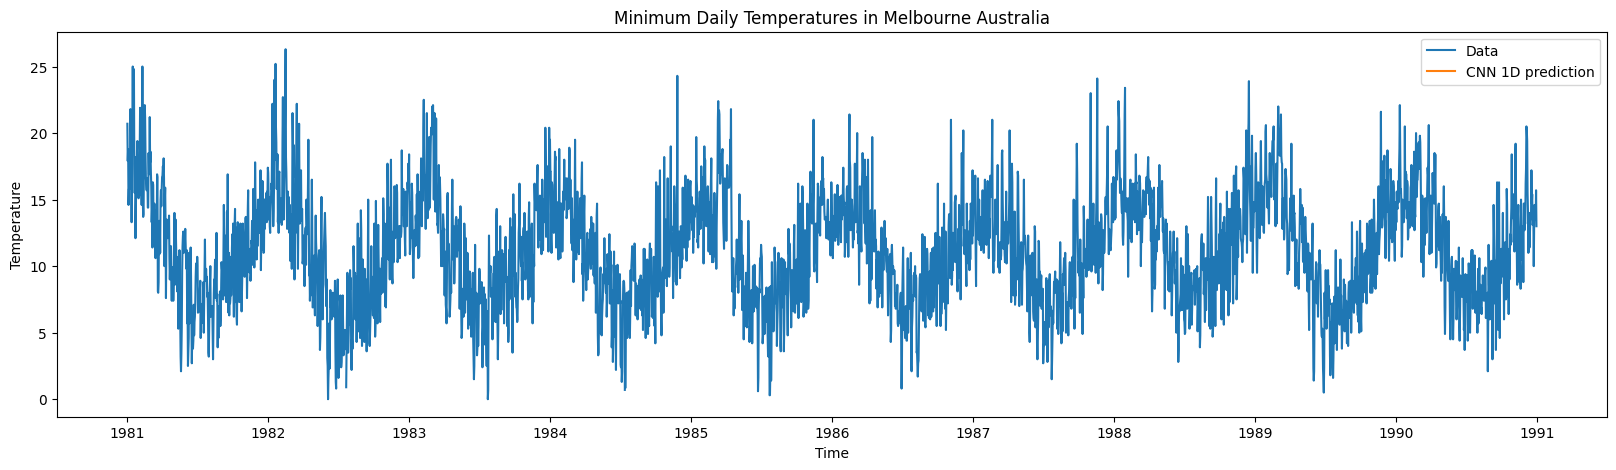

In [17]:
plt.figure(figsize = (20, 5))

# Graficamos la serie completa original
plt.plot(data['Date'], data[col], label="Data")

# Graficamos la predicción en su posición correspondiente en el tiempo
x_axis_pred = data['Date'].iloc[train_size + window + ndays : train_size + window + ndays + len(y_pred)]
plt.plot(x_axis_pred, y_pred, label="CNN 1D prediction")

plt.title("Minimum Daily Temperatures in Melbourne Australia")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.show()